# Analisis Sentimen & Aspek Ulasan Strava (Riset Analisis Sentimen Target: Jurnal Publikasi Ilmiah Aspek)
**Peneliti**: Syifa Pajril Yaum  
Notebook ini didesain **khusus untuk visualisasi & eksplorasi grafis** dengan memanggil backend modular dari `src/preprocess.py` dan `src/train_classical.py`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.train_classical import load_and_split_data, train_and_benchmark_models

# Setting estetika visual standar jurnal ilmiah
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 150

## 1. Eksplorasi Data & Distribusi Sentimen per Aspek

In [2]:
df = pd.read_csv('strava_reviews_processed.csv')
print(f"Total Data Bersih: {len(df):,} baris")
df[['content', 'clean_text', 'sentiment_label', 'aspect_category']].head(5)

Total Data Bersih: 9,843 baris


,content,clean_text,sentiment_label,aspect_category
0,Gps ngelag asu,gps lambat asu,NEGATIVE,GPS_TRACKING
1,good,good,POSITIVE,GENERAL
2,"mau masuk ke apk'nya pakai email,tapi kenapa g...",mau masuk aplikasi nya pakai email tapi tidak,NEGATIVE,GENERAL
3,can't login👎,can t login,NEGATIVE,GENERAL
4,Tolong perbaiki lagi ketika berlari di dalam g...,tolong perbaiki lagi ketika berlari di gedung ...,POSITIVE,GPS_TRACKING


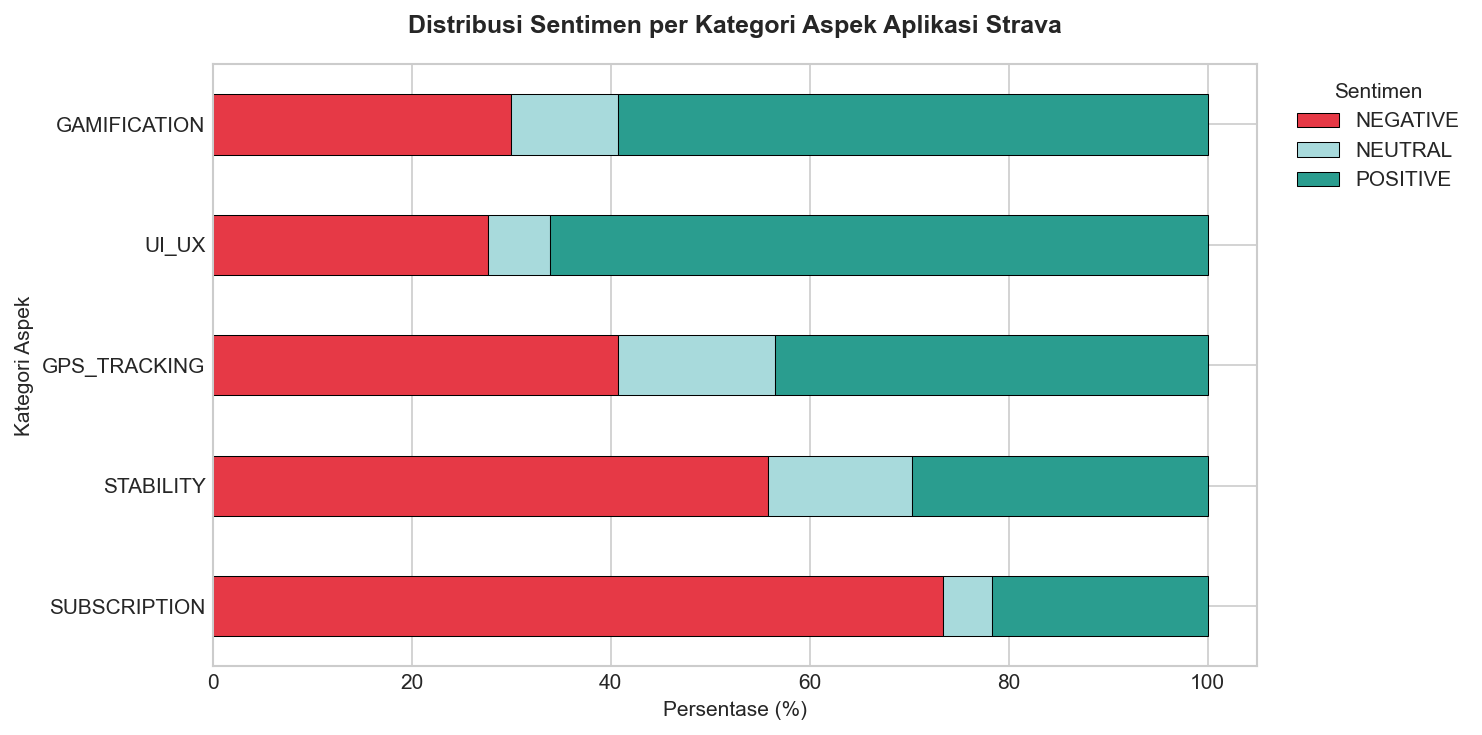

In [3]:
# Visualisasi 1: Distribusi Sentimen pada 5 Aspek Kunci (Cross-tabulation)
ct = pd.crosstab(df['aspect_category'], df['sentiment_label'], normalize='index') * 100
order_aspects = ['SUBSCRIPTION', 'STABILITY', 'GPS_TRACKING', 'UI_UX', 'GAMIFICATION']
ct_ordered = ct.reindex(order_aspects)[['NEGATIVE', 'NEUTRAL', 'POSITIVE']]

fig, ax = plt.subplots(figsize=(10, 5))
ct_ordered.plot(kind='barh', stacked=True, color=['#e63946', '#a8dadc', '#2a9d8f'], ax=ax, edgecolor='black', linewidth=0.5)
ax.set_title('Distribusi Sentimen per Kategori Aspek Aplikasi Strava', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Persentase (%)', fontsize=10)
ax.set_ylabel('Kategori Aspek', fontsize=10)
ax.legend(title='Sentimen', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 2. Benchmark Model Machine Learning Klasik
Memanggil pipeline modular (`src/train_classical.py`): Stratified Split (80:20) + TF-IDF (1,2) + Benchmark MNB, Linear SVM, dan Random Forest.

In [4]:
X_train, X_test, y_train, y_test = load_and_split_data('strava_reviews_processed.csv')
benchmark = train_and_benchmark_models(X_train, X_test, y_train, y_test)

summary_df = benchmark['summary_table']
summary_df

[*] Mengekstraksi fitur TF-IDF (n-gram: (1, 2) , max_features: 5000 )...
[*] Melatih model: Multinomial Naive Bayes...
[*] Melatih model: Linear SVM...
[*] Melatih model: Random Forest...


,Model,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),Train Time (s)
0,Linear SVM,83.70,63.98,65.39,64.62,0.11
1,Multinomial Naive Bayes,86.54,88.27,60.88,58.90,0.01
2,Random Forest,84.76,62.57,60.24,58.76,0.56


## 3. Visualisasi Confusion Matrix untuk Naskah Jurnal

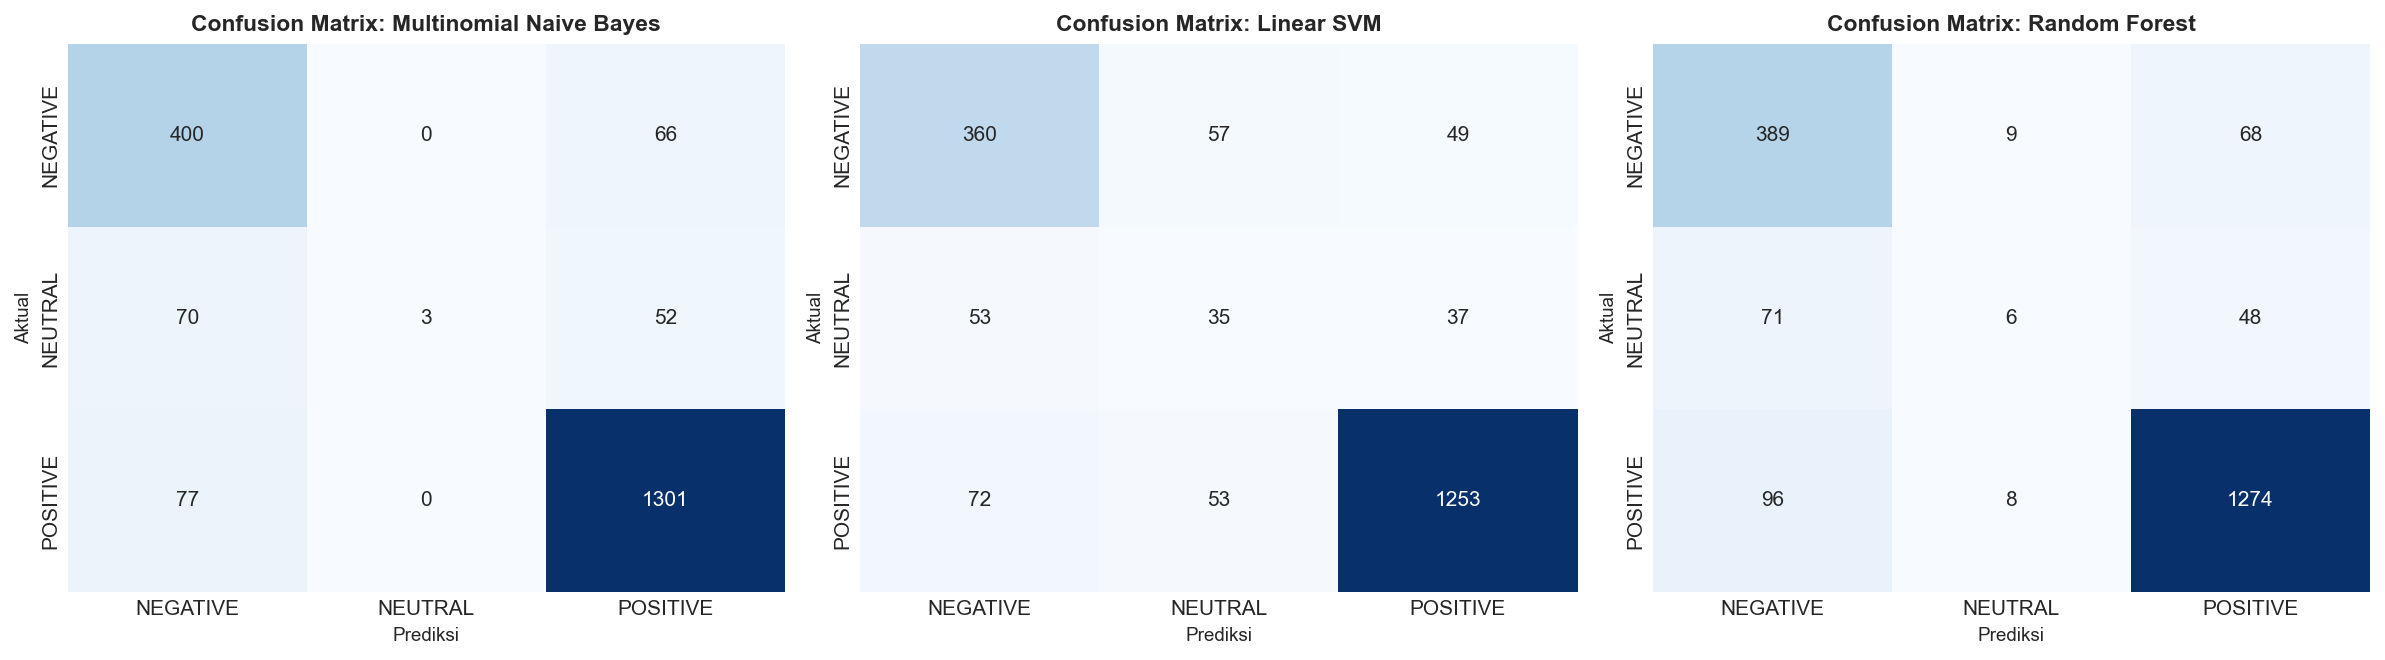

In [5]:
labels = benchmark['labels_order']
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for idx, (name, details) in enumerate(benchmark['detailed_results'].items()):
    cm = details['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                xticklabels=labels, yticklabels=labels, cbar=False)
    axes[idx].set_title(f'Confusion Matrix: {name}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Prediksi', fontsize=9)
    axes[idx].set_ylabel('Aktual', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
"""
Modul Fine-Tuning IndoBERT (indobenchmark/indobert-base-p1) untuk Klasifikasi Sentimen 3-Kelas
Arsitektur: Transformer Sequence Classification + RTX 3050 CUDA Acceleration
Standar: Riset Jurnal Publikasi Ilmiah (Ponytail / Zero-Bloat)
"""

import os
import torch
import numpy as np
import pandas as pd
from typing import Dict
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)
from datasets import Dataset

# Mapping Label Sentimen ke ID Numerik
LABEL_TO_ID = {"NEGATIVE": 0, "NEUTRAL": 1, "POSITIVE": 2}
ID_TO_LABEL = {0: "NEGATIVE", 1: "NEUTRAL", 2: "POSITIVE"}
MODEL_NAME = "indobenchmark/indobert-base-p1"
OUTPUT_DIR = "./results_indobert"


def compute_metrics(eval_pred) -> Dict[str, float]:
    """Menghitung metrik Macro F1, Precision, Recall, dan Accuracy untuk evaluasi jurnal."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    return {
        "accuracy": round(acc * 100, 2),
        "precision_macro": round(precision * 100, 2),
        "recall_macro": round(recall * 100, 2),
        "f1_macro": round(f1 * 100, 2)
    }


def main():
    # 1. Device check
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("=" * 60)
    print(f"[*] Menjalankan Training IndoBERT pada Device: {device.upper()}")
    if device == "cuda":
        print(f"[*] GPU Name: {torch.cuda.get_device_name(0)}")
        print(f"[*] VRAM Available: {round(torch.cuda.get_device_properties(0).total_memory / (1024**3), 2)} GB")
    print("=" * 60)

    # 2. Muat dan Split Data
    csv_file = "strava_reviews_processed.csv"
    if not os.path.exists(csv_file):
        raise FileNotFoundError(f"File {csv_file} belum ada! Jalankan src/preprocess.py terlebih dahulu.")
    
    print(f"[*] Membaca data: {csv_file}...")
    df = pd.read_csv(csv_file).dropna(subset=["clean_text", "sentiment_label"])
    df["label"] = df["sentiment_label"].map(LABEL_TO_ID)

    train_df, test_df = train_test_split(
        df, test_size=0.2, random_state=42, stratify=df["label"]
    )
    print(f"[+] Data Train: {len(train_df)} | Data Test/Eval: {len(test_df)}")

    # 3. Tokenisasi
    print(f"[*] Memuat Tokenizer: {MODEL_NAME}...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    def tokenize_fn(batch):
        return tokenizer(batch["clean_text"], truncation=True, max_length=128)

    train_ds = Dataset.from_pandas(train_df[["clean_text", "label"]])
    test_ds = Dataset.from_pandas(test_df[["clean_text", "label"]])

    print("[*] Melakukan tokenisasi dataset...")
    train_tokenized = train_ds.map(tokenize_fn, batched=True, remove_columns=["clean_text"])
    test_tokenized = test_ds.map(tokenize_fn, batched=True, remove_columns=["clean_text"])

    # 4. Inisialisasi Model
    print(f"[*] Menginisialisasi Pretrained Model: {MODEL_NAME}...")
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=3,
        id2label=ID_TO_LABEL,
        label2id=LABEL_TO_ID
    )

    # 5. Konfigurasi Training Arguments (Disesuaikan untuk VRAM 6GB RTX 3050)
    training_args = TrainingArguments(
        output_dir=OUTPUT_DIR,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        fp16=torch.cuda.is_available(), # Aktifkan Mixed Precision jika GPU ready
        logging_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        report_to="none"
    )

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tokenized,
        eval_dataset=test_tokenized,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    # 6. Training Execution
    print("\n[*] Memulai Proses Fine-Tuning IndoBERT...")
    train_result = trainer.train()
    print("[OK] Fine-Tuning Selesai!")

    # 7. Evaluasi Akhir
    print("\n[*] Menjalankan Evaluasi Akhir pada Test Set...")
    eval_results = trainer.evaluate()
    print("\n=== Hasil Benchmark IndoBERT (Standar Publikasi Ilmiah) ===")
    print(f"Accuracy         : {eval_results.get('eval_accuracy', 0)}%")
    print(f"Precision (Macro): {eval_results.get('eval_precision_macro', 0)}%")
    print(f"Recall (Macro)   : {eval_results.get('eval_recall_macro', 0)}%")
    print(f"F1-Score (Macro) : {eval_results.get('eval_f1_macro', 0)}%")

    # Simpan model terbaik
    save_path = "./models/indobert_sentiment_best"
    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)
    print(f"\n[OK] Model terbaik disimpan di folder: '{save_path}'")


if __name__ == "__main__":
    main()


c:\Users\seeva\.venvs\nlp-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[*] Menjalankan Training IndoBERT pada Device: CUDA
[*] GPU Name: NVIDIA GeForce RTX 3050 6GB Laptop GPU
[*] VRAM Available: 6.0 GB
[*] Membaca data: strava_reviews_processed.csv...
[+] Data Train: 7874 | Data Test/Eval: 1969
[*] Memuat Tokenizer: indobenchmark/indobert-base-p1...
[*] Melakukan tokenisasi dataset...


Map: 100%|██████████| 1969/1969 [00:00<00:00, 63626.93 examples/s]


[*] Menginisialisasi Pretrained Model: indobenchmark/indobert-base-p1...
